# Permanent-Match Scarcity Experiment

Set `relationship_length = ∞` so matches are permanent. Once a couple forms:
- They are **removed from the grid** (their cell becomes EMPTY), so they don't block unmatched agents' neighbourhoods.
- They stop acting entirely.

This turns the market into a **one-shot depletion process**: good agents exit early, leaving a progressively lower-quality pool for latecomers. This is "induced scarcity" — strategies that match quickly face a richer pool; slow strategies are left with whoever remains.

### New metric: average rank
Instead of raw compatibility score, we measure the **rank** of each agent's final partner in that agent's personal preference ordering (built from their observation memory at the moment of matching). Rank 0 = best person they had ever observed; rank 10 = 11th best, etc.

Lower average rank = better outcome (you matched with someone near the top of your list).

### Implementation strategy
We do **not** modify `dating_market.py`. Instead we:
1. Monkey-patch `Agent.act()` to set `engaged_until = np.inf` on a match and remove both partners from the grid.
2. Record the partner's rank in the proposer's memory at the moment of matching.
3. Run the market until it stalls (no new matches for several steps), not for a fixed number of steps.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product
from dating_market import DatingMarket, Agent

## 1. Patched `act()` — permanent match + grid removal

In [2]:
def _permanent_act(self) -> None:
    """
    Replacement for Agent.act() that:
      - sets engaged_until = inf on a successful match (permanent)
      - removes both partners from the grid so they don't occupy space
      - records the rank of the matched partner in the proposer's memory
    """
    self.partner = None  # reset any expired partnership (shouldn't happen with inf, but keeps the interface clean)
    target = self._choose_target()
    if target is None:
        return

    other = self.model.subjects[target]
    if other.consider_proposal(self.id):
        # --- permanent engagement ---
        self.partner = target
        other.partner = self.id
        self.engaged_until = np.inf
        other.engaged_until = np.inf
        self.utility += 1.0

        # --- record rank for both partners at moment of matching ---
        self.match_rank = _rank_of(self, target)
        other.match_rank = _rank_of(other, self.id)
        self.match_time = self.model.t
        other.match_time = self.model.t

        # --- remove both from the grid (cell → EMPTY) ---
        self.model.grid[self.pos] = DatingMarket.EMPTY
        self.model.grid[other.pos] = DatingMarket.EMPTY
        # pos is left as-is on the agent object; it's just no longer on the grid
    else:
        self.utility -= self.rejection_cost


def _rank_of(agent: Agent, partner_id: int) -> int | None:
    """
    Rank of partner_id in `agent`'s current memory, sorted by mean observed
    compatibility (highest first). Returns None if partner was never observed.
    """
    if partner_id not in agent._cnt:
        return None
    # build a dict: other_id -> mean observed compatibility
    means = {}
    for oid, cnt in agent._cnt.items():
        n = min(cnt, agent.memory_depth)
        if n > 0:
            means[oid] = float(np.mean(agent._buf[oid][:n]))
    # sort by descending mean — rank 0 is the best
    ranked = sorted(means, key=lambda x: -means[x])
    try:
        return ranked.index(partner_id)
    except ValueError:
        return None


# Monkey-patch Agent.act with our permanent version
Agent.act = _permanent_act

## 2. Helper: initialise per-agent tracking fields

In [3]:
def _init_tracking(market: DatingMarket) -> None:
    """Add match_rank and match_time attributes to all agents (None until matched)."""
    for a in market.subjects:
        a.match_rank = None
        a.match_time = None

## 3. Run function for the permanent-match market

In [4]:
def run_permanent(
    rejection_cost: float,
    rationality: float,
    gender_balance: float,
    seed: int,
    n: int = 240,
    n_grid: int = 50,
    max_steps: int = 400,
    stall_window: int = 20,   # stop if no new matches in this many steps
    memory_depth: int = 8,
    relation_threshold: float = 0.6,
) -> dict:
    """
    Run one permanent-match simulation.

    Returns a dict with:
      matched_fraction  - fraction of agents that ever matched
      mean_quality      - mean true compatibility of matched pairs
      mean_rank         - mean rank of matched partner in own memory (lower = better)
      mean_match_time   - mean step at which agents matched (earlier = faster)
    """
    m = DatingMarket(
        n_grid=n_grid,
        interaction_std=0.5,
        interaction_radius=5,
        relationship_length=10,  # irrelevant — act() overrides with inf
        seed=seed,
    )
    m.add_agents(
        n,
        gender_balance=gender_balance,
        rejection_cost=rejection_cost,
        rationality=rationality,
        relation_threshold=relation_threshold,
        memory_depth=memory_depth,
        move_prob=0.5,
    )
    _init_tracking(m)

    prev_matched = 0
    stall_count = 0

    for _ in range(max_steps):
        m.step()
        now_matched = sum(not a.is_single for a in m.subjects)
        if now_matched == prev_matched:
            stall_count += 1
        else:
            stall_count = 0
            prev_matched = now_matched
        if stall_count >= stall_window:
            break  # market has cleared

    matched = [a for a in m.subjects if not a.is_single]
    mf = len(matched) / len(m.subjects)
    quality = float(np.mean([m.compatibility(a.id, a.partner) for a in matched])) if matched else np.nan
    ranks = [a.match_rank for a in matched if a.match_rank is not None]
    times = [a.match_time for a in matched if a.match_time is not None]

    return {
        "matched_fraction": mf,
        "mean_quality":     quality,
        "mean_rank":        float(np.mean(ranks)) if ranks else np.nan,
        "mean_match_time":  float(np.mean(times)) if times else np.nan,
    }


def replicate_permanent(seeds=range(8), **kw) -> pd.DataFrame:
    """Run `run_permanent` across multiple seeds, return a DataFrame of results."""
    return pd.DataFrame([run_permanent(seed=s, **kw) for s in seeds])

## 4. Sanity check — single run

In [5]:
result = run_permanent(rejection_cost=1.0, rationality=6.0, gender_balance=0.5, seed=42)
print("Single-run results:")
for k, v in result.items():
    print(f"  {k:20s}: {v:.3f}")

Single-run results:
  matched_fraction    : 0.900
  mean_quality        : 0.752
  mean_rank           : 1.116
  mean_match_time     : 3.417


## 5. Parameter sweep — same parameters as StrategyTest

Sweep `rejection_cost`, `rationality`, and `gender_balance` to see how they affect
quality, rank, and match timing in the permanent-match market.

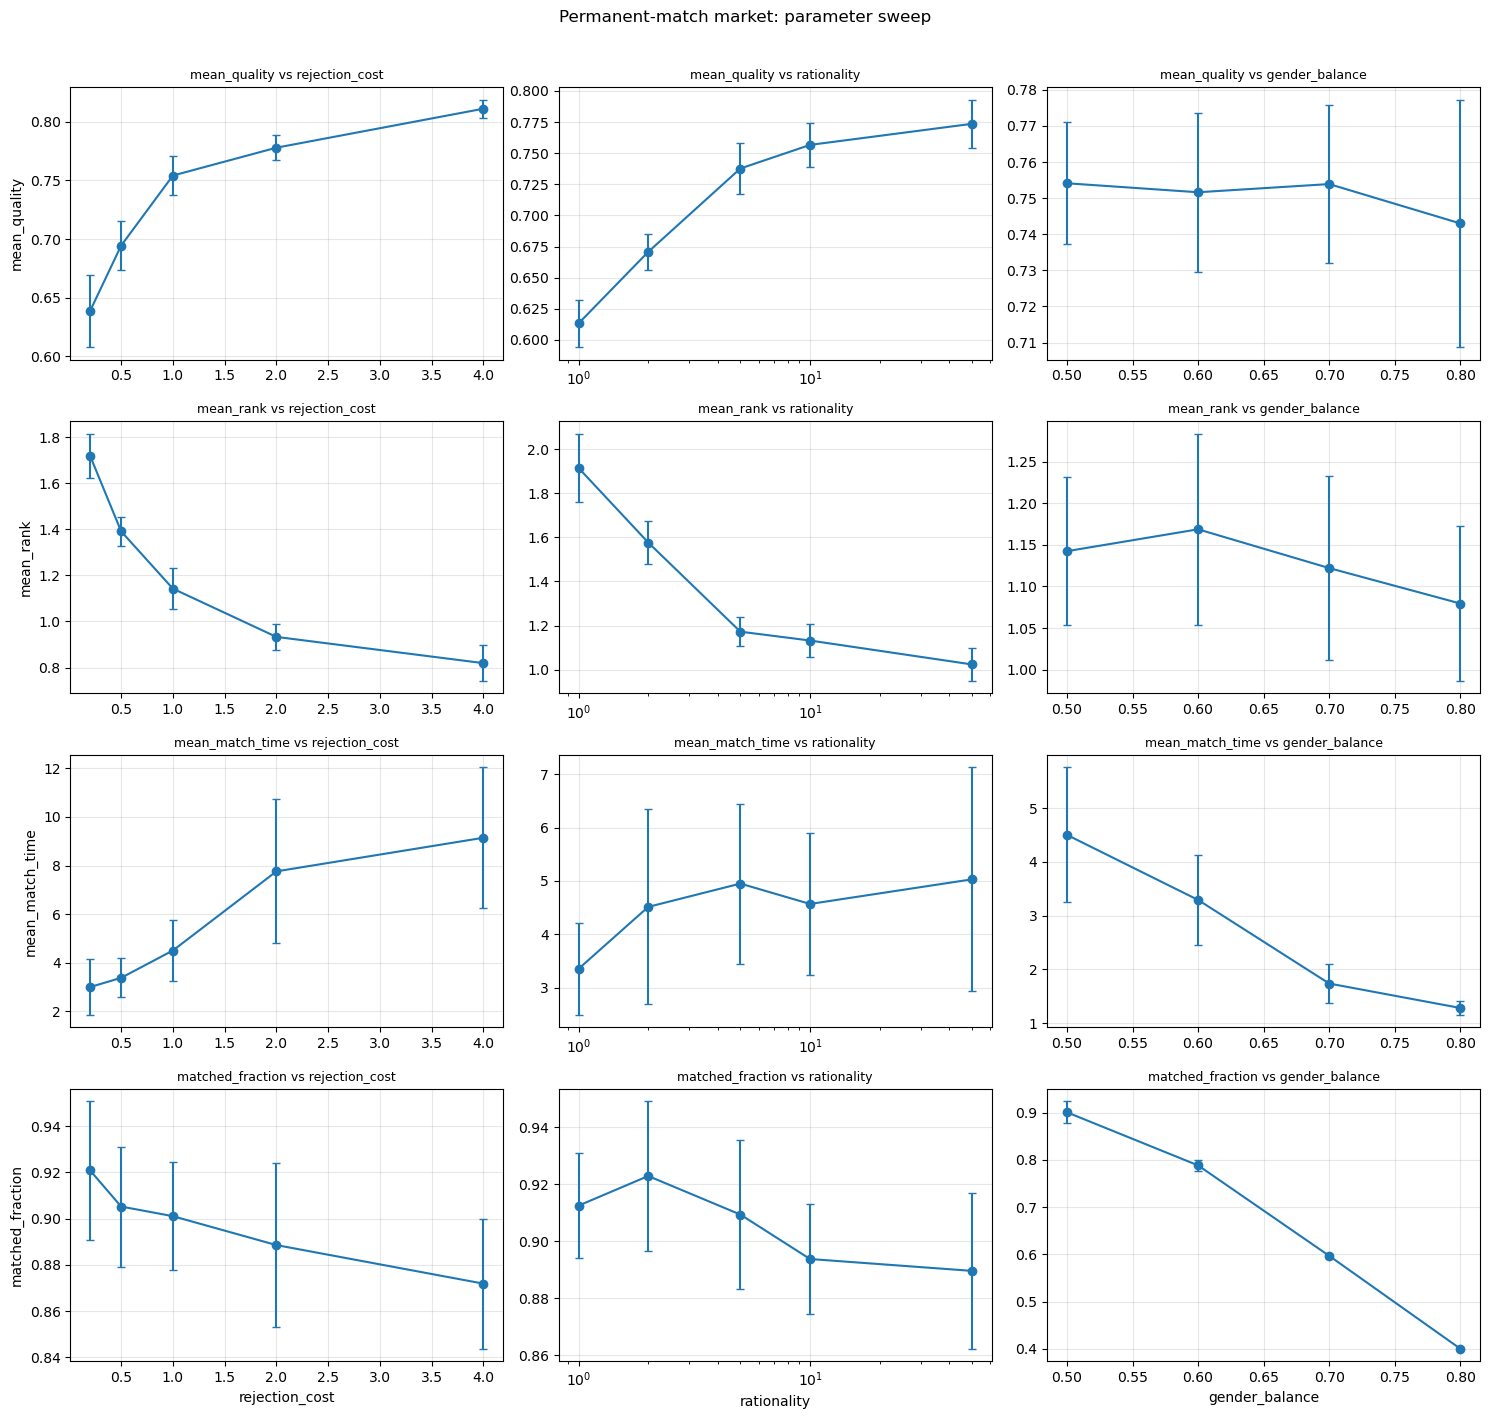

In [6]:
BASE = dict(rejection_cost=1.0, rationality=6.0, gender_balance=0.5)
sweeps = {
    "rejection_cost": [0.2, 0.5, 1.0, 2.0, 4.0],
    "rationality":    [1.0, 2.0, 5.0, 10.0, 50.0],
    "gender_balance": [0.5, 0.6, 0.7, 0.8],
}

metrics = ["mean_quality", "mean_rank", "mean_match_time", "matched_fraction"]
fig, axes = plt.subplots(len(metrics), len(sweeps), figsize=(15, 14))

for col, (param, values) in enumerate(sweeps.items()):
    results_per_value = []
    for v in values:
        kw = {**BASE, param: v}
        df = replicate_permanent(**kw)
        results_per_value.append(df)

    for row, metric in enumerate(metrics):
        ax = axes[row, col]
        means = [df[metric].mean() for df in results_per_value]
        stds  = [df[metric].std()  for df in results_per_value]
        ax.errorbar(values, means, yerr=stds, marker="o", capsize=3)
        ax.set_title(f"{metric} vs {param}", fontsize=9)
        ax.grid(alpha=0.3)
        if row == len(metrics) - 1:
            ax.set_xlabel(param)
        if col == 0:
            ax.set_ylabel(metric)
        if param == "rationality":
            ax.set_xscale("log")

fig.suptitle("Permanent-match market: parameter sweep", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## 6. Strategy competition — who benefits from scarcity?

Same four strategies as StrategyTest. In a depletion market, bold strategies
match early (rich pool); cautious strategies wait and may face a depleted pool.
Does the competitive ranking flip compared to the renewable market?

In [7]:
def run_mixed_permanent(
    strategies: list[dict],
    seed: int,
    gb: float = 0.5,
    n_per: int = 80,
    n_grid: int = 50,
    max_steps: int = 400,
    stall_window: int = 20,
    thr: float = 0.6,
    memory_depth: int = 8,
) -> dict[str, dict]:
    """
    Run a mixed-strategy permanent-match market.
    Returns per-strategy means of quality, rank, match_time, and matched_fraction.
    """
    m = DatingMarket(
        n_grid=n_grid,
        interaction_std=0.5,
        interaction_radius=5,
        relationship_length=10,
        seed=seed,
    )
    sid_to_label = {}
    for st in strategies:
        sid = m.add_agents(
            n_per,
            gender_balance=gb,
            rejection_cost=st["rejection_cost"],
            rationality=st["rationality"],
            relation_threshold=thr,
            memory_depth=memory_depth,
            move_prob=0.5,
            label=st["label"],
        )
        sid_to_label[sid] = st["label"]
    _init_tracking(m)

    prev_matched = 0
    stall_count = 0
    for _ in range(max_steps):
        m.step()
        now_matched = sum(not a.is_single for a in m.subjects)
        if now_matched == prev_matched:
            stall_count += 1
        else:
            stall_count = 0
            prev_matched = now_matched
        if stall_count >= stall_window:
            break

    out = {}
    for sid, label in sid_to_label.items():
        members = [a for a in m.subjects if a.strategy_id == sid and not a.is_single]
        n_total = sum(1 for a in m.subjects if a.strategy_id == sid)
        quality   = np.mean([m.compatibility(a.id, a.partner) for a in members]) if members else np.nan
        ranks     = [a.match_rank  for a in members if a.match_rank  is not None]
        times     = [a.match_time  for a in members if a.match_time  is not None]
        out[label] = {
            "mean_quality":     float(np.nanmean([quality])),
            "mean_rank":        float(np.mean(ranks))  if ranks else np.nan,
            "mean_match_time":  float(np.mean(times))  if times else np.nan,
            "matched_fraction": len(members) / n_total if n_total else np.nan,
        }
    return out


strat_grid = [
    dict(rejection_cost=0.2, rationality=50.0, label="bold-rational"),
    dict(rejection_cost=4.0, rationality=50.0, label="cautious-rational"),
    dict(rejection_cost=0.2, rationality=1.0,  label="bold-random"),
    dict(rejection_cost=4.0, rationality=1.0,  label="cautious-random"),
]
seeds = range(8)

# collect results across seeds
rows = []
for s in seeds:
    res = run_mixed_permanent(strat_grid, seed=s)
    for label, metrics_dict in res.items():
        rows.append({"seed": s, "strategy": label, **metrics_dict})
mixed_df = pd.DataFrame(rows)

summary = mixed_df.groupby("strategy")[["mean_quality", "mean_rank", "mean_match_time", "matched_fraction"]].mean()
print("Mixed-strategy results (permanent market):")
print(summary.round(3))

Mixed-strategy results (permanent market):
                   mean_quality  mean_rank  mean_match_time  matched_fraction
strategy                                                                     
bold-random               0.649      2.738            4.011             0.936
bold-rational             0.706      1.979            3.165             0.958
cautious-random           0.731      1.802            5.819             0.919
cautious-rational         0.781      1.076            6.719             0.831


## 7. Compare: does the competitive ranking flip vs. the renewable market?

Bold strategies should match earlier in the permanent market (richer pool). Does that
translate to *better* quality, or do they still lose to cautious agents in absolute terms?

/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_94117/3153517834.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=20, ha="right")
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_94117/3153517834.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=20, ha="right")
/var/folders/z1/7kbjhk_n18x0w1rlzpp72dl40000gn/T/ipykernel_94117/3153517834.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(strategies, rotation=20, ha="right")


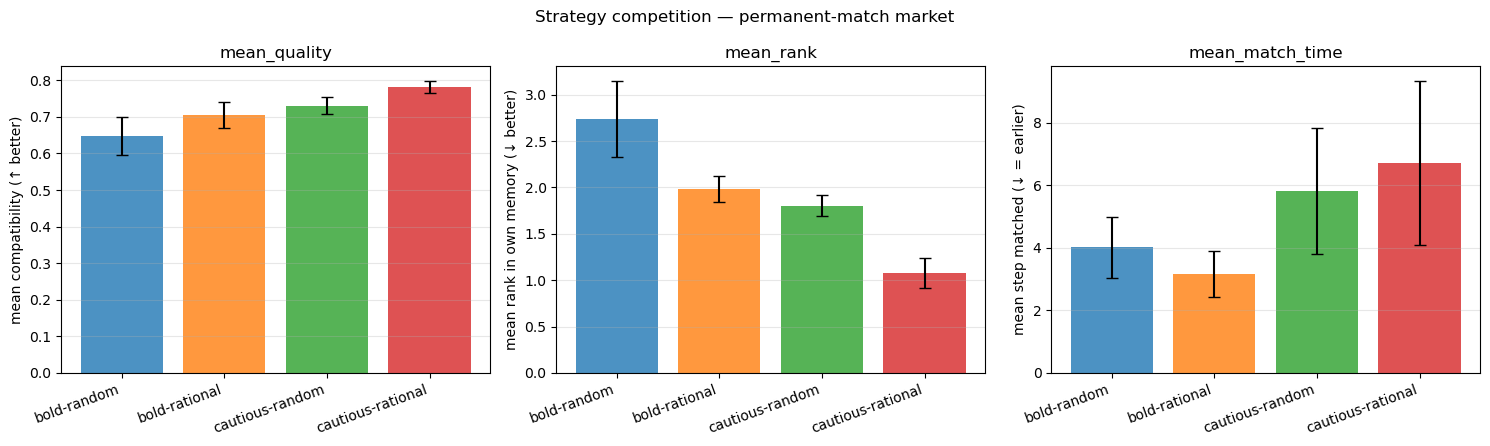

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
strategies = summary.index.tolist()
colors = ["C0", "C1", "C2", "C3"]

for ax, metric, ylabel in zip(
    axes,
    ["mean_quality", "mean_rank", "mean_match_time"],
    ["mean compatibility (↑ better)", "mean rank in own memory (↓ better)", "mean step matched (↓ = earlier)"],
):
    vals = summary[metric]
    errs = mixed_df.groupby("strategy")[metric].std()
    ax.bar(strategies, [vals[s] for s in strategies],
           yerr=[errs[s] for s in strategies],
           color=colors, capsize=4, alpha=0.8)
    ax.set_title(metric)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(strategies, rotation=20, ha="right")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Strategy competition — permanent-match market", fontsize=12)
plt.tight_layout()
plt.show()

## 8. Match timing distribution — who exits early?

Histogram of match times per strategy. This shows *when* each strategy type
clears the market, which is the core depletion story.

## 9. Single utility welfare — does the balance point appear under gender imbalance?

assign a baseline utility `u_s` to being single, then compute total welfare as:

```
total_welfare = matched_fraction * mean_quality + (1 - matched_fraction) * u_s
```

In the balanced renewable market (gb=0.5), matched fraction barely changes with rejection_cost
so cautious always wins — no balance point exists. But in the permanent market with gender
imbalance, cautious agents risk being stranded (matched fraction drops steeply). That tradeoff
should produce a peak somewhere in the middle — the balance point Johan predicted.

We sweep rejection_cost × gender_balance and plot total welfare for several values of u_s.

In [9]:
# --- Step 1: sweep rejection_cost x gender_balance in the permanent market ---
rejection_costs  = [0.2, 0.5, 1.0, 2.0, 4.0]
gender_balances  = [0.5, 0.6, 0.7, 0.8]
N_SEEDS          = 8

sweep_rows = []
for gb in gender_balances:
    for rc in rejection_costs:
        df = replicate_permanent(
            seeds=range(N_SEEDS),
            rejection_cost=rc,
            rationality=6.0,      # fixed — same as baseline sweep
            gender_balance=gb,
        )
        sweep_rows.append({
            "gender_balance":    gb,
            "rejection_cost":    rc,
            "mean_quality":      df["mean_quality"].mean(),
            "matched_fraction":  df["matched_fraction"].mean(),
        })

sweep_df = pd.DataFrame(sweep_rows)
print(sweep_df.round(3))

    gender_balance  rejection_cost  mean_quality  matched_fraction
0              0.5             0.2         0.639             0.921
1              0.5             0.5         0.694             0.905
2              0.5             1.0         0.754             0.901
3              0.5             2.0         0.778             0.889
4              0.5             4.0         0.811             0.872
5              0.6             0.2         0.654             0.795
6              0.6             0.5         0.704             0.786
7              0.6             1.0         0.752             0.789
8              0.6             2.0         0.789             0.773
9              0.6             4.0         0.822             0.761
10             0.7             0.2         0.674             0.599
11             0.7             0.5         0.693             0.600
12             0.7             1.0         0.754             0.597
13             0.7             2.0         0.798             0

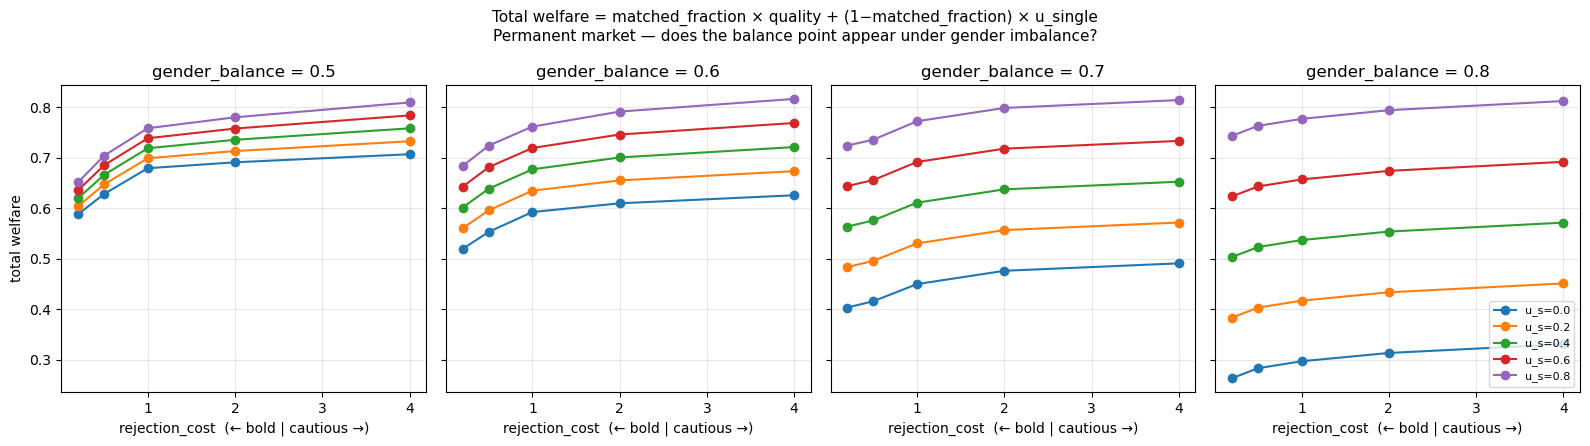

In [10]:
# --- Step 2: compute total welfare for each (gb, rc, u_s) combination ---
single_utilities = [0.0, 0.2, 0.4, 0.6, 0.8]

fig, axes = plt.subplots(
    1, len(gender_balances),
    figsize=(16, 4.5),
    sharey=True,
)

for ax, gb in zip(axes, gender_balances):
    sub = sweep_df[sweep_df["gender_balance"] == gb].copy()

    for su in single_utilities:
        sub["total_welfare"] = (
            sub["matched_fraction"] * sub["mean_quality"]
            + (1 - sub["matched_fraction"]) * su
        )
        ax.plot(
            sub["rejection_cost"],
            sub["total_welfare"],
            marker="o",
            label=f"u_s={su}",
        )

    ax.set_title(f"gender_balance = {gb}")
    ax.set_xlabel("rejection_cost  (← bold | cautious →)")
    ax.grid(alpha=0.3)
    if gb == gender_balances[0]:
        ax.set_ylabel("total welfare")
    if gb == gender_balances[-1]:
        ax.legend(fontsize=8)

fig.suptitle(
    "Total welfare = matched_fraction × quality + (1−matched_fraction) × u_single\n"
    "Permanent market — does the balance point appear under gender imbalance?",
    fontsize=11,
)
plt.tight_layout()
plt.show()

In [12]:
# --- Step 3: for each (gb, u_s), find the optimal rejection_cost ---
# If the balance point exists, optimal rc should shift LEFT (toward bold) as u_s rises
# and as gender_balance rises (more stranding risk).

print("Optimal rejection_cost given gender_balance and single_utility:")
print(f"{'':15s}", end="")
for su in single_utilities:
    print(f"  u_s={su}", end="")
print()

for gb in gender_balances:
    sub = sweep_df[sweep_df["gender_balance"] == gb].copy()
    print(f"gb={gb:<10}", end="")
    for su in single_utilities:
        sub["total_welfare"] = (
            sub["matched_fraction"] * sub["mean_quality"]
            + (1 - sub["matched_fraction"]) * su
        )
        best_rc = sub.loc[sub["total_welfare"].idxmax(), "rejection_cost"]
        print(f"  {best_rc:>7.1f}", end="")
    print()

Optimal rejection_cost given gender_balance and single_utility:
                 u_s=0.0  u_s=0.2  u_s=0.4  u_s=0.6  u_s=0.8
gb=0.5             4.0      4.0      4.0      4.0      4.0
gb=0.6             4.0      4.0      4.0      4.0      4.0
gb=0.7             4.0      4.0      4.0      4.0      4.0
gb=0.8             4.0      4.0      4.0      4.0      4.0


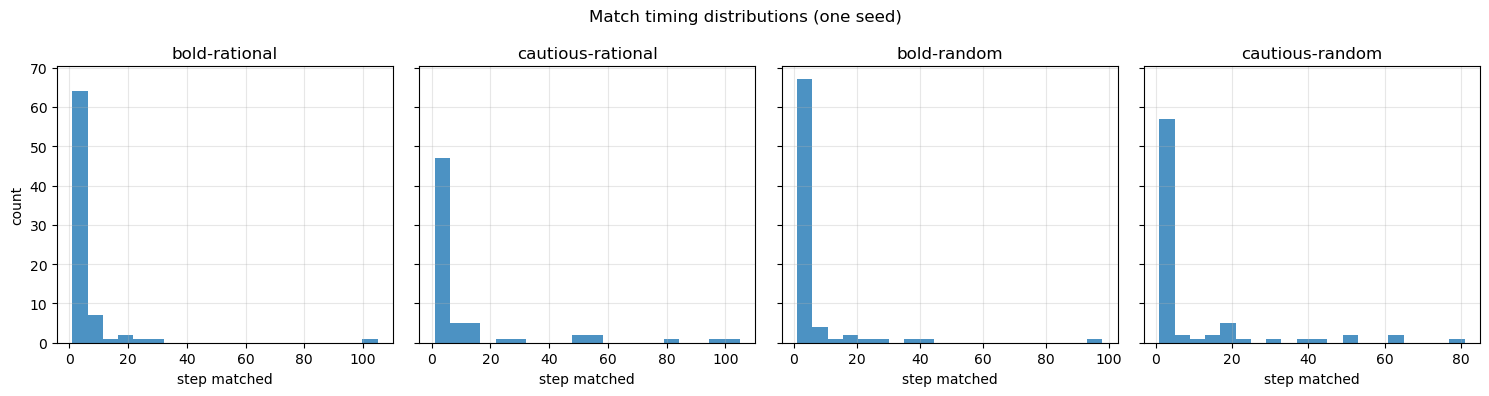

In [13]:
# Run one seed in detail to get per-agent match times
m_detail = DatingMarket(
    n_grid=50, interaction_std=0.5, interaction_radius=5,
    relationship_length=10, seed=0,
)
sid_to_label = {}
for st in strat_grid:
    sid = m_detail.add_agents(
        80, gender_balance=0.5, rejection_cost=st["rejection_cost"],
        rationality=st["rationality"], relation_threshold=0.6,
        memory_depth=8, move_prob=0.5, label=st["label"],
    )
    sid_to_label[sid] = st["label"]
_init_tracking(m_detail)

prev_matched = 0
stall_count = 0
for _ in range(400):
    m_detail.step()
    now_matched = sum(not a.is_single for a in m_detail.subjects)
    if now_matched == prev_matched:
        stall_count += 1
    else:
        stall_count = 0
        prev_matched = now_matched
    if stall_count >= 20:
        break

fig, axes = plt.subplots(1, len(strat_grid), figsize=(15, 4), sharey=True)
for ax, st in zip(axes, strat_grid):
    sid = next(k for k, v in sid_to_label.items() if v == st["label"])
    times = [
        a.match_time for a in m_detail.subjects
        if a.strategy_id == sid and a.match_time is not None
    ]
    ax.hist(times, bins=20, alpha=0.8)
    ax.set_title(st["label"])
    ax.set_xlabel("step matched")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("count")
fig.suptitle("Match timing distributions (one seed)", fontsize=12)
plt.tight_layout()
plt.show()